# Welded Beam q=1 decision shift

This notebook is the human-readable, CPU-compatible record of the prospectively frozen three-state experiment.

## 1. Question

Do six ordinary uncertain engineering constraints create large posterior-to-decision shift at the points constrained EI actually prefers, and does that shift make practical scrambled-Sobol estimation unreliable?

## 2. Why Welded Beam

BoTorch's standard single-objective Welded Beam problem has four design variables and six physically recognizable black-box constraints. It removes the q=4, heavy-tail, and numerical-reference complications that invalidated the previous Hartmann attempt. This experiment tests the mechanism with ordinary independent Gaussian GPs and q=1 only.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'experiments' / 'welded_beam_shift' / 'config.json').exists():
    ROOT = ROOT.parent
CONFIG = ROOT / 'experiments' / 'welded_beam_shift' / 'config.json'
OUTPUT = ROOT / 'experiments' / 'welded_beam_shift' / 'outputs'
sys.path.insert(0, str(ROOT / 'src'))
from decision_tilt.welded_beam import load_config
from decision_tilt.welded_beam_experiment import run_experiment
config, protocol_hash = load_config(CONFIG)
print('Protocol hash:', protocol_hash)

Protocol hash: eed30cb385f2a49aea06f235593e590e056e2c49655950376988d9fbe109b777


## 3. Frozen protocol

The constants below are read from the committed protocol rather than repeated by hand. Each state uses one fixed feasible anchor plus 63 prospective Sobol points. The anchor is necessary because only about 0.1% of the standard domain is jointly feasible.

In [2]:
display({
    'states': config['states'],
    'gp': config['gp'],
    'candidates': config['candidates'],
    'qmc': config['qmc'],
    'prospective_gate': config['prospective_gate'],
})

{'states': {'seeds': [4101, 4102, 4103],
  'training_size': 64,
  'sobol_points_per_state': 63,
  'fixed_feasible_anchor_raw': [0.3, 5.0, 8.0, 0.4]},
 'gp': {'dtype': 'torch.float64',
  'train_only_population_standardization': True,
  'standardized_fixed_noise_variance': 1e-06,
  'standardization_scale_floor': 1e-12,
  'posterior_variance_floor': 1e-12,
  'model': 'SingleTaskGP-default-constant-mean-ARD-RBF',
  'optimizer': 'fit_gpytorch_mll_scipy',
  'maximum_iterations': 200},
 'candidates': {'seed': 5201,
  'count': 16384,
  'prediction_chunk_size': 2048,
  'qmc_chunk_size': 512,
  'top_k': 32,
  'top_percentages': [1, 5],
  'representative_state_seed': 4102},
 'qmc': {'sample_counts': [64, 128, 256, 512, 1024],
  'scramble_repetitions': 64,
  'scramble_seed_base': 620100,
  'dimension': 7,
  'common_random_numbers_across_candidates': True,
  'nested_sample_prefixes': True},
 'prospective_gate': {'shift_positive_top32_median_ess_maximum': 0.125,
  'qmc_failure_sample_count': 512,
  

## 4. Exact mathematics

For independent Gaussian objective and constraint beliefs, constrained EI is $E[I]p_F$. Because the feasibility indicator squares to itself, $E[U^2]=E[I^2]p_F$. Therefore $D_2=\log E[I^2]-2\log E[I]-\log p_F$ and the population ESS fraction is $e^{-D_2}$. No Monte Carlo reference is needed. The implementation evaluates far-negative improvement tails with a stable asymptotic expansion and checks selected values by adaptive quadrature.

## 5. Three frozen states

Run the complete frozen CPU experiment once. Progress messages expose all three states and every nested QMC count. No state may be replaced after seeing its result.

In [3]:
summary = run_experiment(CONFIG, OUTPUT)
print('Final prospective status:', summary['gate']['status'])
print('Runtime seconds:', round(summary['runtime_seconds'], 2))

[STATE 1/3] fitting objective + 6 constraint GPs ...


[STATE 1/3] fitting objective + 6 constraint GPs ... done


[STATE 1/3] exact cEI / ESS over candidate set ... done


[STATE 1/3] QMC N=64 ... done


[STATE 1/3] QMC N=128 ... done


...

[STATE 3/3] QMC N=256 ... done


[STATE 3/3] QMC N=512 ... done


[STATE 3/3] QMC N=1024 ... done


[STATE 3/3] complete: top32 ESS=0.0874, 512 regret=0.0000, 512 disagreement=0.0414


Final prospective status: WELDED_BEAM_SHIFT_NEGATIVE_REVIEW_REQUIRED
Runtime seconds: 118.75


## 6. Decision-shift results

Low ESS matters only when it occurs among competitive constrained-EI candidates. The table reports the exact top-32 and top-1% regions for every frozen state.

In [4]:
state_summary = pd.read_csv(OUTPUT / 'state_summary.csv')
display(state_summary)

,state_seed,training_size,observed_feasible_count,incumbent,exact_best_candidate,exact_best_log_constrained_ei,exact_best_ess_fraction,top32_median_ess_fraction,top1_median_ess_fraction,top1_fraction_ess_at_most_one_eighth,candidate_truth_feasible_fraction,all_gp_fits_converged,moment_log_error,state_seconds
0,4101,64,1,-3.422207,12707,1.023698,0.408905,0.113316,0.000187,0.908537,0.001038,True,4.440892e-16,40.057419
1,4102,64,1,-3.422207,4764,0.399691,0.429221,0.074482,0.000676,0.957317,0.001038,True,3.330669e-16,39.585221
2,4103,64,1,-3.422207,15676,0.089945,0.136023,0.087407,0.009450,0.945122,0.001038,True,4.440892e-16,39.082020


## 7. QMC ranking results

The primary reliability quantities are selected-candidate acquisition regret and pairwise ranking disagreement within the exact top 32. Exact-best selection is also shown but is not itself a gate because near ties can make it pessimistic.

In [5]:
qmc_summary = pd.read_csv(OUTPUT / 'qmc_summary.csv')
display(qmc_summary[qmc_summary.sample_count.isin([256, 512])])

,state_seed,sample_count,mean_normalized_regret,regret_lower_95,regret_upper_95,mean_pairwise_disagreement,pairwise_lower_95,pairwise_upper_95,exact_best_selection_probability,one_percent_optimal_probability,mean_kendall_tau,mean_top32_overlap
2,4101,256,0.0,0.0,0.0,0.021390,0.020067,0.022713,1.0,1.0,0.957220,0.986816
3,4101,512,0.0,0.0,0.0,0.011530,0.010522,0.012569,1.0,1.0,0.976941,0.995605
7,4102,256,0.0,0.0,0.0,0.030179,0.028572,0.031754,1.0,1.0,0.939642,0.959961
8,4102,512,0.0,0.0,0.0,0.019437,0.018145,0.020728,1.0,1.0,0.961127,0.969238
12,4103,256,0.0,0.0,0.0,0.063382,0.060578,0.066249,1.0,1.0,0.873236,0.973145
13,4103,512,0.0,0.0,0.0,0.041425,0.039378,0.043567,1.0,1.0,0.917150,0.978516


## 8. Main figures

Figure A asks where shift occurs, Figure B shows practical QMC reliability, and Figure C decomposes the mechanism in the prospectively designated representative State 4102.

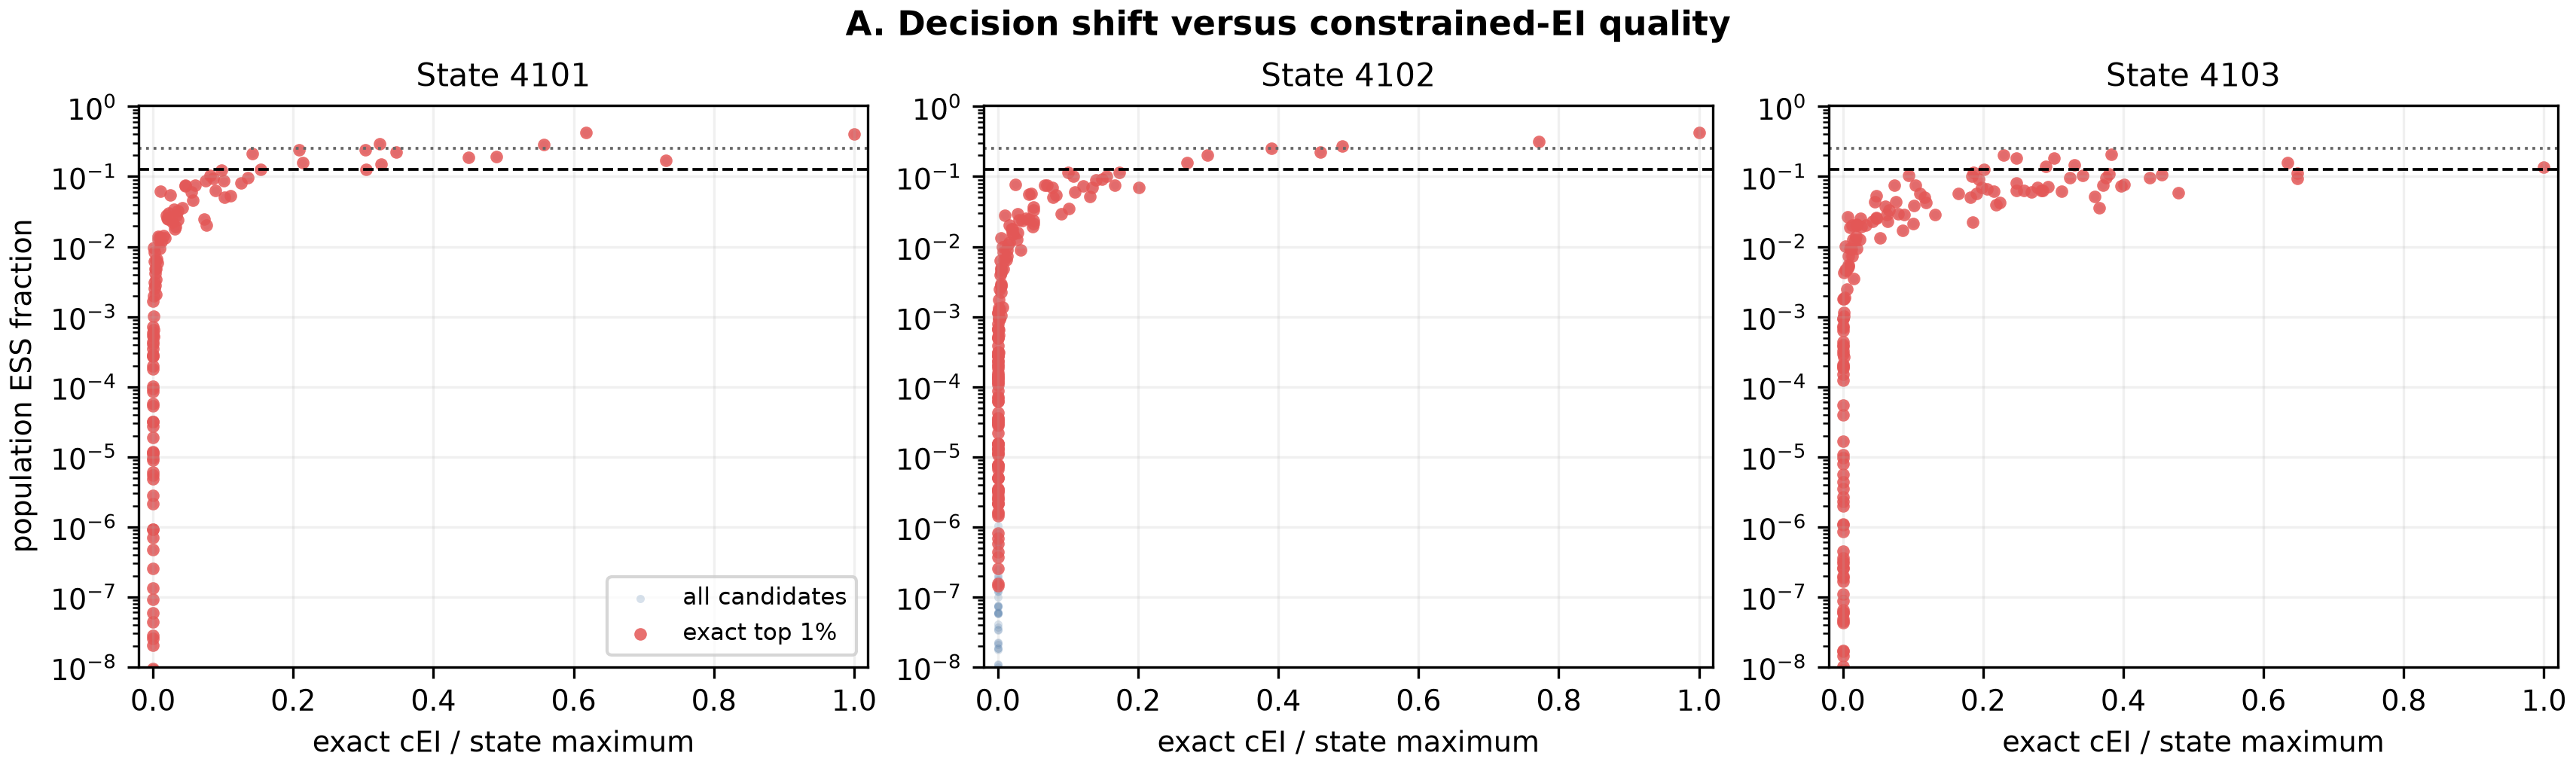

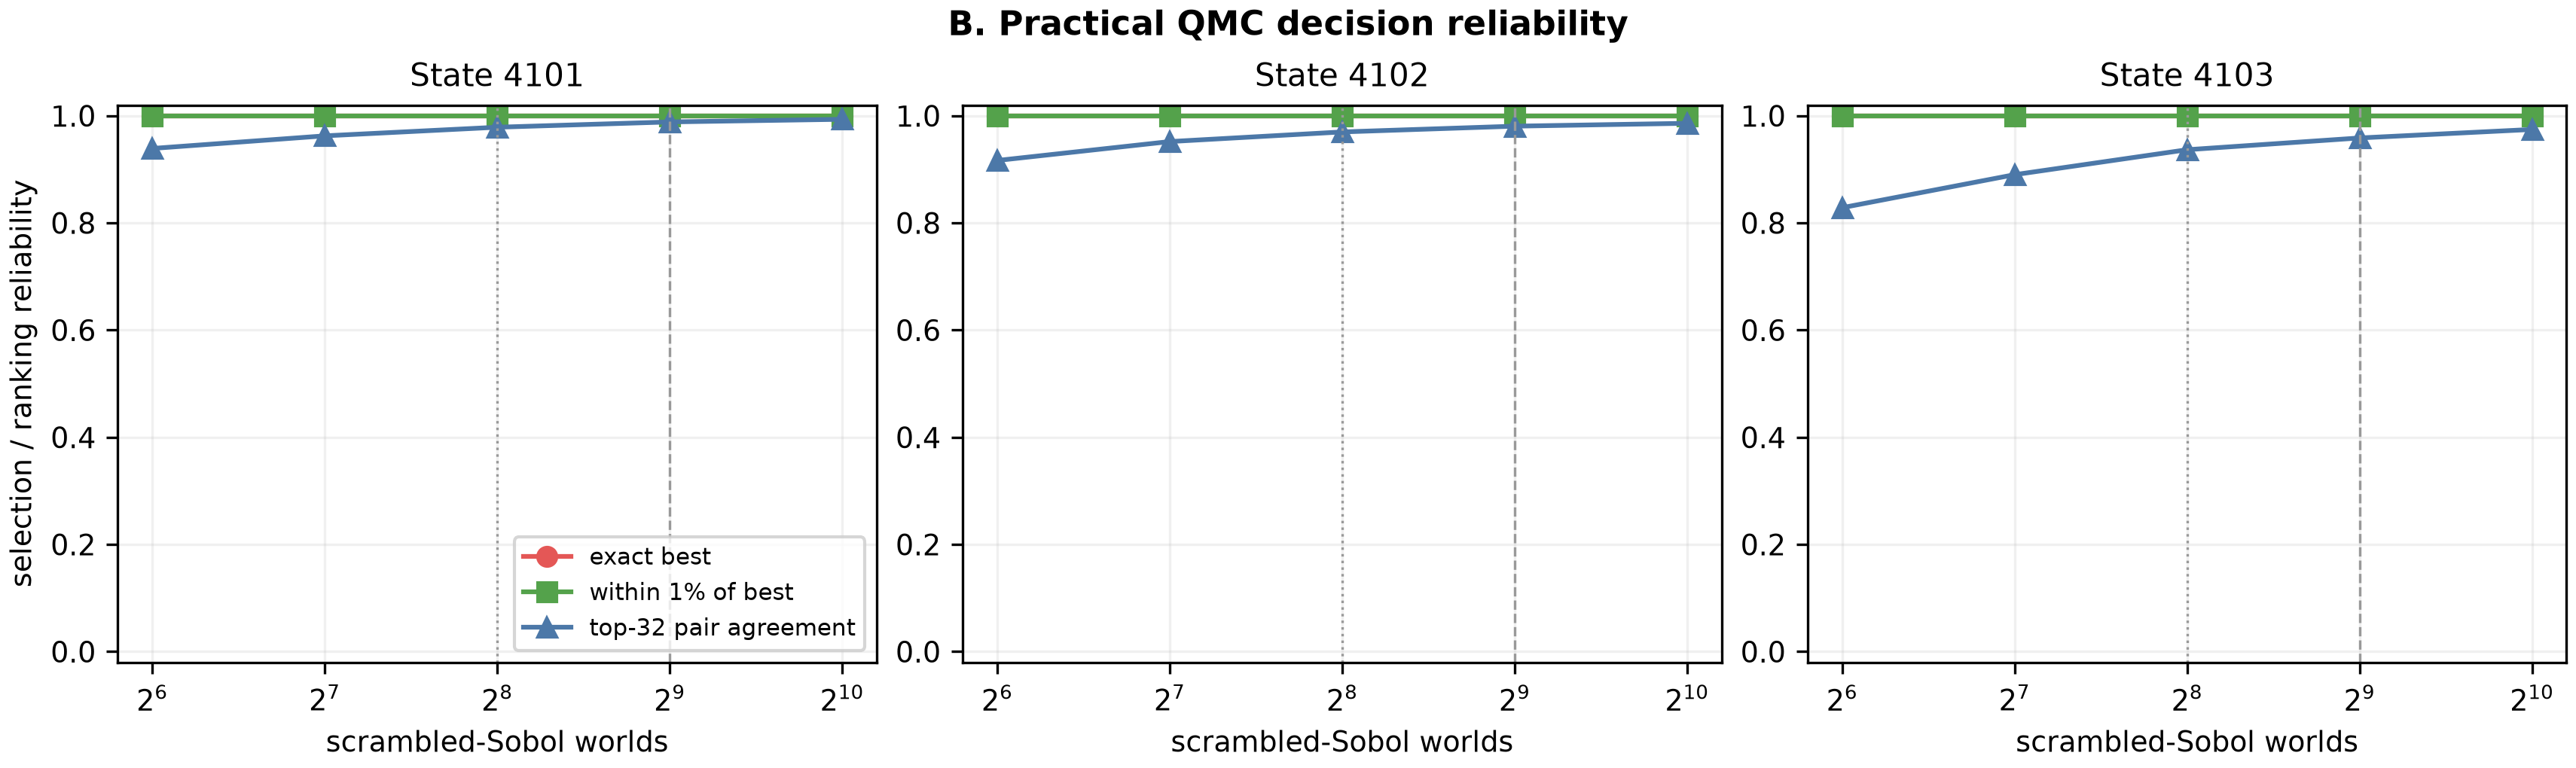

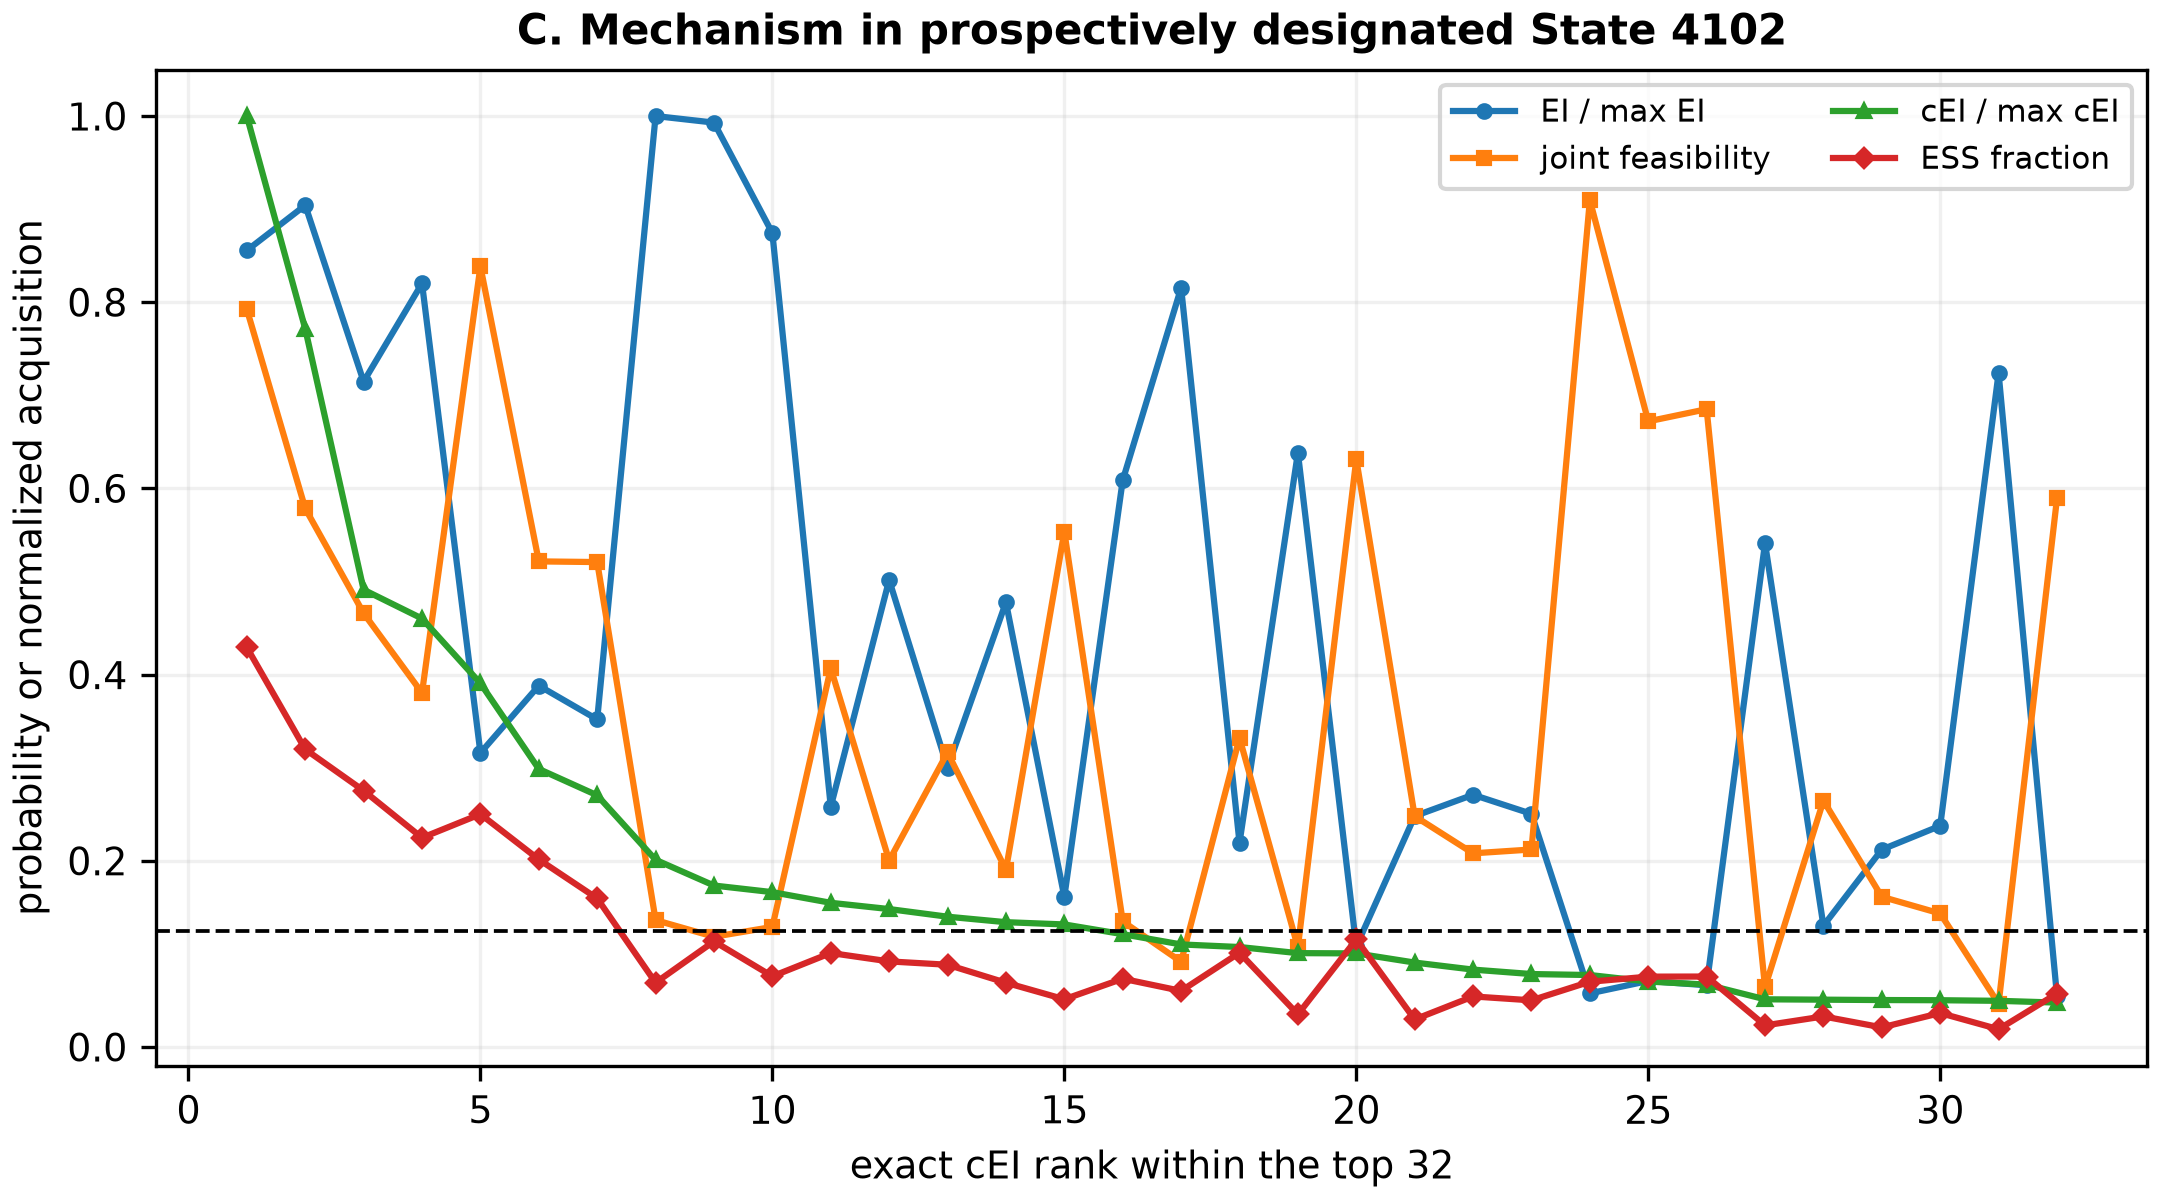

In [6]:
for filename in ['figure_a_shift_vs_quality.png', 'figure_b_qmc_reliability.png', 'figure_c_mechanism.png']:
    display(Image(filename=str(OUTPUT / filename)))

## 9. Interpretation

A meaningful positive result requires the same states to show low ESS among their exact best candidates and material QMC regret plus ranking error at 512 samples. Low ESS among bad candidates, or harmless misordering of near ties, is not positive evidence.

In [7]:
gate = json.loads((OUTPUT / 'gate_result.json').read_text())
display(gate)

{'status': 'WELDED_BEAM_SHIFT_NEGATIVE_REVIEW_REQUIRED',
 'valid': True,
 'positive_state_count': 0,
 'negative_state_count': 2,
 'state_checks': {'4101': {'shift_positive': True,
   'qmc_failure_positive': False,
   'joint_positive': False,
   'shift_negative': False,
   'qmc_reliable': True,
   'conclusively_negative': True},
  '4102': {'shift_positive': True,
   'qmc_failure_positive': False,
   'joint_positive': False,
   'shift_negative': False,
   'qmc_reliable': True,
   'conclusively_negative': True},
  '4103': {'shift_positive': True,
   'qmc_failure_positive': False,
   'joint_positive': False,
   'shift_negative': False,
   'qmc_reliable': False,
   'conclusively_negative': False}},
 'protocol_version': 'welded-beam-shift-v1',
 'protocol_hash': 'eed30cb385f2a49aea06f235593e590e056e2c49655950376988d9fbe109b777',
 'git_sha': '1db67fae9ba7ab3859d8cb96c5d4327a65f6a2e0'}

## 10. GO / NO-GO

The status above is computed mechanically from the prospective protocol. A positive label still requires human review; a negative label is evidence against escalating complexity. An invalid numerical check yields an inconclusive review state.

## 11. Next human decision

Review the three figures, exact state table, QMC intervals, and gate record. Do not automatically authorize q=4, non-Gaussian beliefs, or a decision-adapted inference method.